# Table of contents

* **Introduction**
* **Objective**
* **Pipeline Overview**
* **Data Dictionary**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Text Cleaning**
* **Model Training (TextRank)**
    * Extractive Summarization using TextRank and Similarity Matrix Validation
    * Algorithms Explanation and Hyperparameters Impact Analysis
    * Automated Hyperparameter Tuning (Optuna)
* **Model Evaluation**
    * Test Prediction
    * ROUGE and BLEU score Evaluation
* **Conclusion**
* **References**

# Introduction

This project demonstrates the application of TextRank, an unsupervised, graph-based algorithm designed for extractive text summarization. The methodology is applied to the BBC News Summary dataset, which contains full news articles and their corresponding human-written summaries across five distinct categories: business, entertainment, politics, sport, and technology. TextRank, drawing inspiration from Google's PageRank algorithm, operates by ranking sentences based on their calculated similarity and overall importance within a document. The final summary is constructed by selecting the top-ranked sentences. This approach effectively showcases the generation of informative summaries without relying on labeled training data or complex deep learning architectures.

# Objective

The primary objective of this project is to implement and validate the TextRank algorithm for summarizing news articles. The workflow is designed to provide an end-to-end demonstration, spanning from raw text processing to the final evaluation of the generated summaries. Specific goals include:

- Implementation of the TextRank algorithm on the news articles for extractive summarization.
- Exploration of the impact of critical hyperparameters (such as the number of sentences to extract, the n-gram range for vectorization, and the minimum document frequency) on the quality of the resulting summaries.
- Utilization of Optuna for automated hyperparameter optimization, specifically targeting the maximization of the BLEU score.
- Evaluation of the final model's performance using BLEU and ROUGE metrics on a held-out test set.
- Visualization of data characteristics, including distribution and word frequency, alongside the transparent TextRank pipeline for enhanced interpretability.

# Pipeline Overview

The project follows a rigorous, sequential eight-step pipeline to ensure robust modeling and evaluation:

- **Data Loading & Pivoting:** News articles are loaded and aligned with their corresponding reference summaries based on their filename and category.
- **Train/Test Split:** The dataset is sampled, and an 80/20 split is performed, resulting in samples for training (or modeling) and samples for testing and evaluation.
- **Exploratory Data Analysis (EDA):** Initial data quality checks are performed, examining null values, word count distribution, category breakdown, and generating word clouds.
- **Text Preprocessing:** Both articles and summaries undergo cleaning.
- **TextRank Modeling:** Sentence tokenization, TF-IDF vectorization, similarity matrix calculation, and PageRank scoring are executed.
- **Hyperparameter Tuning:** Optuna is employed to optimize the key parameters of the TextRank model.
- **Evaluation:** Final average BLEU and ROUGE scores are computed on the dedicated test set.
- **Visualization:** Key aspects of the pipeline, such as the similarity matrix and the step-by-step TextRank flow, are visualized.

# Data Dictionary

    BBC News Summary (Root Folder)/
    
                - News Articles (Sub-folder: Full Text)/
                
                     - business (Contains article_id.txt, e.g., 001.txt)
                     - entertainment (Contains article_id.txt)
                     - politics (Contains article_id.txt)
                     - sport (Contains article_id.txt)
                     - tech (Contains article_id.txt)

                - Summaries (Sub-folder: Summarized Versions)/
                 
                     - business (Contains summary_id.txt, e.g., 001.txt)
                     - entertainment (Contains summary_id.txt)
                     - politics (Contains summary_id.txt)
                     - sport (Contains summary_id.txt)
                     - tech (Contains summary_id.txt)

**[Dataset Link](https://www.kaggle.com/datasets/pariza/bbc-news-summary/data)**

# Approach

**Type of Text Summarization**

- Extractive: Take up a document and extract important sentences from it as it is i.e. without changing any word. Hence, if the document has 80 sentences, the Extractive method will pick up 5–6 sentences (depending on the user how long a summary he wants) from this lot of 80 sentences without any change. It can be taken as selecting some sentences on the basis of their importance in the document
- Abstractive: Creating a summary from a document depending on the semantics of the document and not exact sentences. Hence, a summary generated this way may have sentences not even used in the document but with the same semantics.

In this project, it is Extractive text summarization.

**Preprocessing Pipeline Approach**

The preprocessing stage is crucial for noise reduction and data normalization, ensuring high-quality input for the TF-IDF vectorization and subsequent similarity computation. The core cleaning function is applied consistently to both news articles and reference summaries across the training and test sets. The process involves:

- Contraction Expansion: Contractions (e.g., "don't") are expanded to their full form ("do not") to improve token consistency.

This approach effectively preserves the core meaning of the sentences while significantly reducing irrelevant terms, resulting in clean text ready for sentence-level TF-IDF transformation. Stemming or lemmatization is intentionally avoided to preserve the original form and readability of the sentences, a necessary consideration for an extractive summarization method.

**Model Training Approach (TextRank)**

**TextRank Algorithm Overview**

- Representing sentences into vectors using the word embedding.
- Preparation of Similarity Matrix.
- Conversion of Similarity Matrix into graph/network to apply the PageRank Algorithm.
- Applying the PageRank Algorithm.
- Extracting summary using top N sentences based on their rankings.

TextRank is an unsupervised algorithm, meaning it does not involve a traditional training phase with gradient descent. Instead, it executes a series of steps on each individual article to determine sentence importance:

- Sentence Tokenization: The raw text of the article is split into individual sentences using `nltk.sent_tokenize()`.
- TF-IDF Vectorization: The sentences are vectorized using TfidfVectorizer. Parameters like the $n$-gram range and minimum document frequency (`min_df`) are configurable.
- Similarity Matrix Construction: Cosine similarity is calculated between the TF-IDF vectors of all sentence pairs. This matrix represents the weighted links in the graph.
- Graph Construction and PageRank: A graph structure is built from the similarity matrix. The PageRank algorithm is then applied to the graph to assign an importance score to every sentence node.
- Ranking and Selection: Sentences are ranked based on their PageRank scores. The top N sentences (`num_sentences`) are selected and then reordered back into their original appearance sequence to form the final summary.

Hyperparameter tuning utilized Optuna to automatically find the optimal configuration with using BLEU as objective for tuning.

**Model Evaluation Approach**

Evaluation is conducted using standard, reference-based metrics computed on the 89 samples in the held-out test set. The generated summaries are compared against their respective human-written reference summaries. The key metrics used are:

- BLEU (Bilingual Evaluation Understudy): Measures $n$-gram overlap, prioritizing precision and rewarding fluent, accurate output. A smoothing function is used to ensure stability with shorter summaries.
- ROUGE-N (Recall-Oriented Understudy for Gisting Evaluation): Measures the overlap of $n$-grams (unigrams for ROUGE-1 and bigrams for ROUGE-2), focusing on recall - how much of the reference summary the generated summary covered.
- ROUGE-L: Measures the overlap of the Longest Common Subsequence (LCS), rewarding the structural similarity of the generated and reference texts.

The moderate BLEU and ROUGE-L scores reflect that while the model is fast and interpretable, extractive methods often exhibit slightly lower structural alignment compared to abstractive models.

# Setup Environments

**Packages Installation**

In [ ]:
%%capture
!pip install rouge_score
!pip install contractions
# !pip install wordcloud
!pip install graphviz networkx matplotlib
!pip install optuna 

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import os
from pathlib import Path
from collections import Counter
from itertools import product

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import contractions

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import sklearn

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Input, Embedding, Dropout, Dense, Layer, LayerNormalization, MultiHeadAttention, LSTM, Bidirectional, Concatenate, TimeDistributed
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from wordcloud import WordCloud, STOPWORDS

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

import networkx as nx
from graphviz import Digraph

import optuna


try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("NLTK 'stopwords' corpus not found. Downloading...")
    nltk.download('stopwords')
    print("NLTK 'stopwords' corpus downloaded.")

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("NLTK 'punkt' tokenizer not found. Downloading...")
    nltk.download('punkt')
    print("NLTK 'punkt' tokenizer downloaded.")

STOPWORDS = set(stopwords.words('english'))

# Data Loading

The primary goal of the load_and_pivot_bbc_news_dataset function is to read the raw text files, which are scattered across different folders, and combine them into a single structured table (DataFrame) where each row contains a complete article and its corresponding summary.

- File System Traversal (`os.walk`): The code uses `os.walk` to recursively navigate the directory structure. This is necessary because the BBC dataset organizes files first by type ('News Articles' vs. 'Summaries') and then by category (e.g., 'business', 'sport').
- Data Matching (Pivoting): The raw files are loaded in a "long" format (one row per file). The key algorithmic challenge is matching an article text file (e.g., 001.txt in 'News Articles') with its summary file (001.txt in 'Summaries'). This is solved using the `pivot_table` function in Pandas.
- Pivot Table Concept: It allows you to reshape a DataFrame. By setting the filename and category as the index, and the `article_or_summary` type as the columns, the text content is automatically aligned. A single row now uniquely represents one article and its summary pair.

In [ ]:
def load_and_pivot_bbc_news_dataset(base_data_path='/kaggle/input/bbc-news-summary/BBC News Summary/'):
    """
    Loads BBC News Summary dataset, including text content, and pivots it
    to match articles with their summaries by filename and category.

    Args:
        base_data_path (str): The base directory where the dataset is located.

    Returns:
        pd.DataFrame: A DataFrame with 'filename', 'category', 'News Articles' text,
                      and 'Summaries' text.
    """
    all_data = []

    for root, dirs, files in os.walk(base_data_path):
        parts = Path(root).parts
        
        if len(parts) >= 2 and (parts[-2] == 'News Articles' or parts[-2] == 'Summaries'):
            article_type = parts[-2]
            category = parts[-1]

            for filename in files:
                full_path = os.path.join(root, filename)
                
                try:
                    with open(full_path, 'r', encoding='utf-8') as f:
                        content = f.read()
                except Exception as e:
                    print(f"Warning: Could not read file {full_path}. Error: {e}")
                    content = ""

                all_data.append({
                    "filename": filename,
                    "category": category,
                    "article_or_summary": article_type,
                    "text_content": content
                })

    df_raw = pd.DataFrame(all_data)

    df_pivoted = df_raw.pivot_table(
        index=['filename', 'category'],
        columns='article_or_summary',
        values='text_content',
        aggfunc='first'
    ).reset_index()

    df_pivoted.columns.name = None

    final_df = df_pivoted[['filename', 'category', 'News Articles', 'Summaries']]
    
    return final_df

df = load_and_pivot_bbc_news_dataset()
df

,filename,category,News Articles,Summaries
0,001.txt,business,Ad sales boost Time Warner profit\n\nQuarterly...,TimeWarner said fourth quarter sales rose 2% t...
1,001.txt,entertainment,Gallery unveils interactive tree\n\nA Christma...,"The messages will be ""unwrapped"" by sculptor R..."
2,001.txt,politics,Labour plans maternity pay rise\n\nMaternity p...,She said her party would boost maternity pay i...
3,001.txt,sport,Claxton hunting first major medal\n\nBritish h...,"For the first time, Claxton has only been prep..."
4,001.txt,tech,Ink helps drive democracy in Asia\n\nThe Kyrgy...,The other common type of ink in elections is i...
...,...,...,...,...
2220,509.txt,business,Euro firms miss out on optimism\n\nMore than 9...,"Possibly as a result, the worry about low-cost..."
2221,509.txt,sport,Melzer shocks Agassi in San Jose\n\nSecond see...,Second seed Andre Agassi suffered a comprehens...
2222,510.txt,business,Lacroix label bought by US firm\n\nLuxury good...,LVMH said the French designer's haute couture ...
2223,510.txt,sport,Mirza makes Indian tennis history\n\nTeenager ...,Teenager Sania Mirza completed a superb week a...


**Data Sampling**

The loaded dataset is sampled and then divided into training and testing subsets.

- Sampling (`df.sample(frac=0.5, random_state=42)`): In large-scale data projects, sampling (taking a subset of data) is sometimes necessary to reduce computational time, particularly during the experimentation phase. The use of `random_state=42` is critical for reproducibility - it ensures that the random selection of rows is the same every time the code is run.
- Train-Test Split (`train_test_split(...)`): This is a fundamental machine learning technique.
    - Training Set (80%): Used to build and train the summarization model.
    - Testing Set (20%): Used to evaluate the model's performance on unseen data. This measures how well the model generalizes and avoids overfitting (performing well only on the data it was trained on).

In [ ]:
df = df.sample(frac=0.5, random_state=42)

print(f"Sampled DataFrame shape (50%): {df.shape}")
print("\nHead of the 50% sampled DataFrame:")
df

Sampled DataFrame shape (50%): (1112, 4)

Head of the 50% sampled DataFrame:


,filename,category,News Articles,Summaries
414,083.txt,tech,Microsoft makes anti-piracy move\n\nMicrosoft ...,Microsoft releases regular security updates to...
420,085.txt,business,Home loan approvals rising again\n\nThe number...,"Mortgage lending rose by £7.1bn in December, u..."
1644,329.txt,tech,Intel unveils laser breakthrough\n\nIntel has ...,While work has been done to make some of the c...
416,084.txt,entertainment,Oscar nominees gear up for lunch\n\nLeonardo D...,Oscar nominees Swank and Foxx were among the w...
1232,247.txt,politics,Kennedy to make temple address\n\nCharles Kenn...,Mr Kennedy will also highlight the anger among...
...,...,...,...,...
1740,349.txt,business,S Korean lender faces liquidation\n\nCreditors...,"""Creditors would seek strong financial sanctio..."
1614,323.txt,tech,Blind student 'hears in colour'\n\nA blind stu...,Mr Wong has been blind from the age of seven a...
1281,257.txt,entertainment,Row threatens Hendrix museum plan\n\nProposals...,"Janie Hendrix, the guitarist's stepsister, sai..."
1905,382.txt,business,Ban on forced retirement under 65\n\nEmployers...,Trade and Industry Secretary Patricia Hewitt s...


**Train and Test Split**

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (889, 4)
test shape: (223, 4)


# Exploratory Data Analysis (EDA)

**Basic Information**

The first section of code checks for missing values (`nulls`) in both the train and test dataframes.

In [5]:
train.isnull().sum()

filename         0
category         0
News Articles    0
Summaries        0
dtype: int64

In [6]:
test.isnull().sum()

filename         0
category         0
News Articles    0
Summaries        0
dtype: int64

The `isnull().sum()` output for both train and test shows all columns (filename, category, News Articles, Summaries) have a value of 0. This is an excellent result, indicating that the dataset has no missing values, which means no imputation or dropping of rows is required due to nulls.

**Articles Contents**

The second section iterates through each unique category in the training data and prints a sample article and its corresponding summary using the following steps:

- Get all unique categories.
- Filter the train DataFrame to select the first row (`.iloc[0]`) belonging to the current category.
- Print the category, filename, the full text from the 'News Articles' column, and the text from the 'Summaries' column.

In [ ]:
print("--- Sample Article and Summary for Each Category ---")

unique_categories = train['category'].unique()

for category in unique_categories:
    sample_row = train[train['category'] == category].iloc[0]

    filename = sample_row['filename']
    article_text = sample_row['News Articles']
    summary_text = sample_row['Summaries']

    print(f"\nCategory: {category} (Filename: {filename})")
    print("-" * (len(category) + 20))

    print("\n--- Full Article ---")
    print(article_text)

    print("\n--- Full Summary ---")
    print(summary_text)

    print("\n" + "="*80 + "\n")

--- Sample Article and Summary for Each Category ---

Category: politics (Filename: 316.txt)
----------------------------

--- Full Article ---
Blair moves to woo Jewish voters

Tony Blair has pledged to "never, ever, ever" attack Tory leader Michael Howard over his Jewish beliefs.

The prime minister told the Jewish Chronicle: "If you look at what I do, I attack Michael Howard politically." Mr Blair also distanced himself from recent Labour campaign posters featuring Mr Howard, which critics claimed were "anti-Semitic". These were "not intended to cause any offence to anyone on the Jewish community," Mr Blair insisted.

One poster depicted Mr Howard and his shadow chancellor Oliver Letwin, who is also Jewish, as flying pigs. Another pictured the Tory leader swinging a pocket watch on a chain, which critics said echoed the Jewish money lender Shylock in Shakespeare's Merchant of Venice.

Others compared the image to the character Fagin in Charles Dickens' Oliver Twist. Labour has since

The Sample Article and Summary section confirms the structure of the data:

- Each entry has a distinct category (e.g., politics, business, tech, sport, entertainment).
- The 'News Articles' column contains the original, long-form text.
- The 'Summaries' column contains a shorter, extract-based version of the article (as seen in the political sample, the summary is a collection of sentences taken directly from the article but not necessarily in the original order).

In [ ]:
def count_words(text):
    if isinstance(text, str):
        return len(text.split())
    return 0

article_word_counts = train['News Articles'].apply(count_words)
summary_word_counts = train['Summaries'].apply(count_words)

longest_article_words = article_word_counts.max()
longest_summary_words = summary_word_counts.max()
overall_longest_words = max(longest_article_words, longest_summary_words)

total_words_articles = article_word_counts.sum()

total_words_summaries = summary_word_counts.sum()

overall_total_words = total_words_articles + total_words_summaries

print(f"Longest number of words in 'News Articles': {longest_article_words}")
print(f"Longest number of words in 'Summaries': {longest_summary_words}")
print(f"Overall longest number of words from both columns: {overall_longest_words}")
print(f"Total number of words in 'News Articles': {total_words_articles}")
print(f"Total number of words in 'Summaries': {total_words_summaries}")
print(f"Overall total number of words in both columns: {overall_total_words}")

Longest number of words in 'News Articles': 4432
Longest number of words in 'Summaries': 2073
Overall longest number of words from both columns: 4432
Total number of words in 'News Articles': 342381
Total number of words in 'Summaries': 148315
Overall total number of words in both columns: 490696


**Article Categories Distributions**

This section generates a bar plot to visualize the number of articles within each category in the training data. The code uses seaborn's countplot to automatically calculate the frequency of each category and plot it. The bars are sorted in descending order of frequency (`order=train['category'].value_counts().index`).

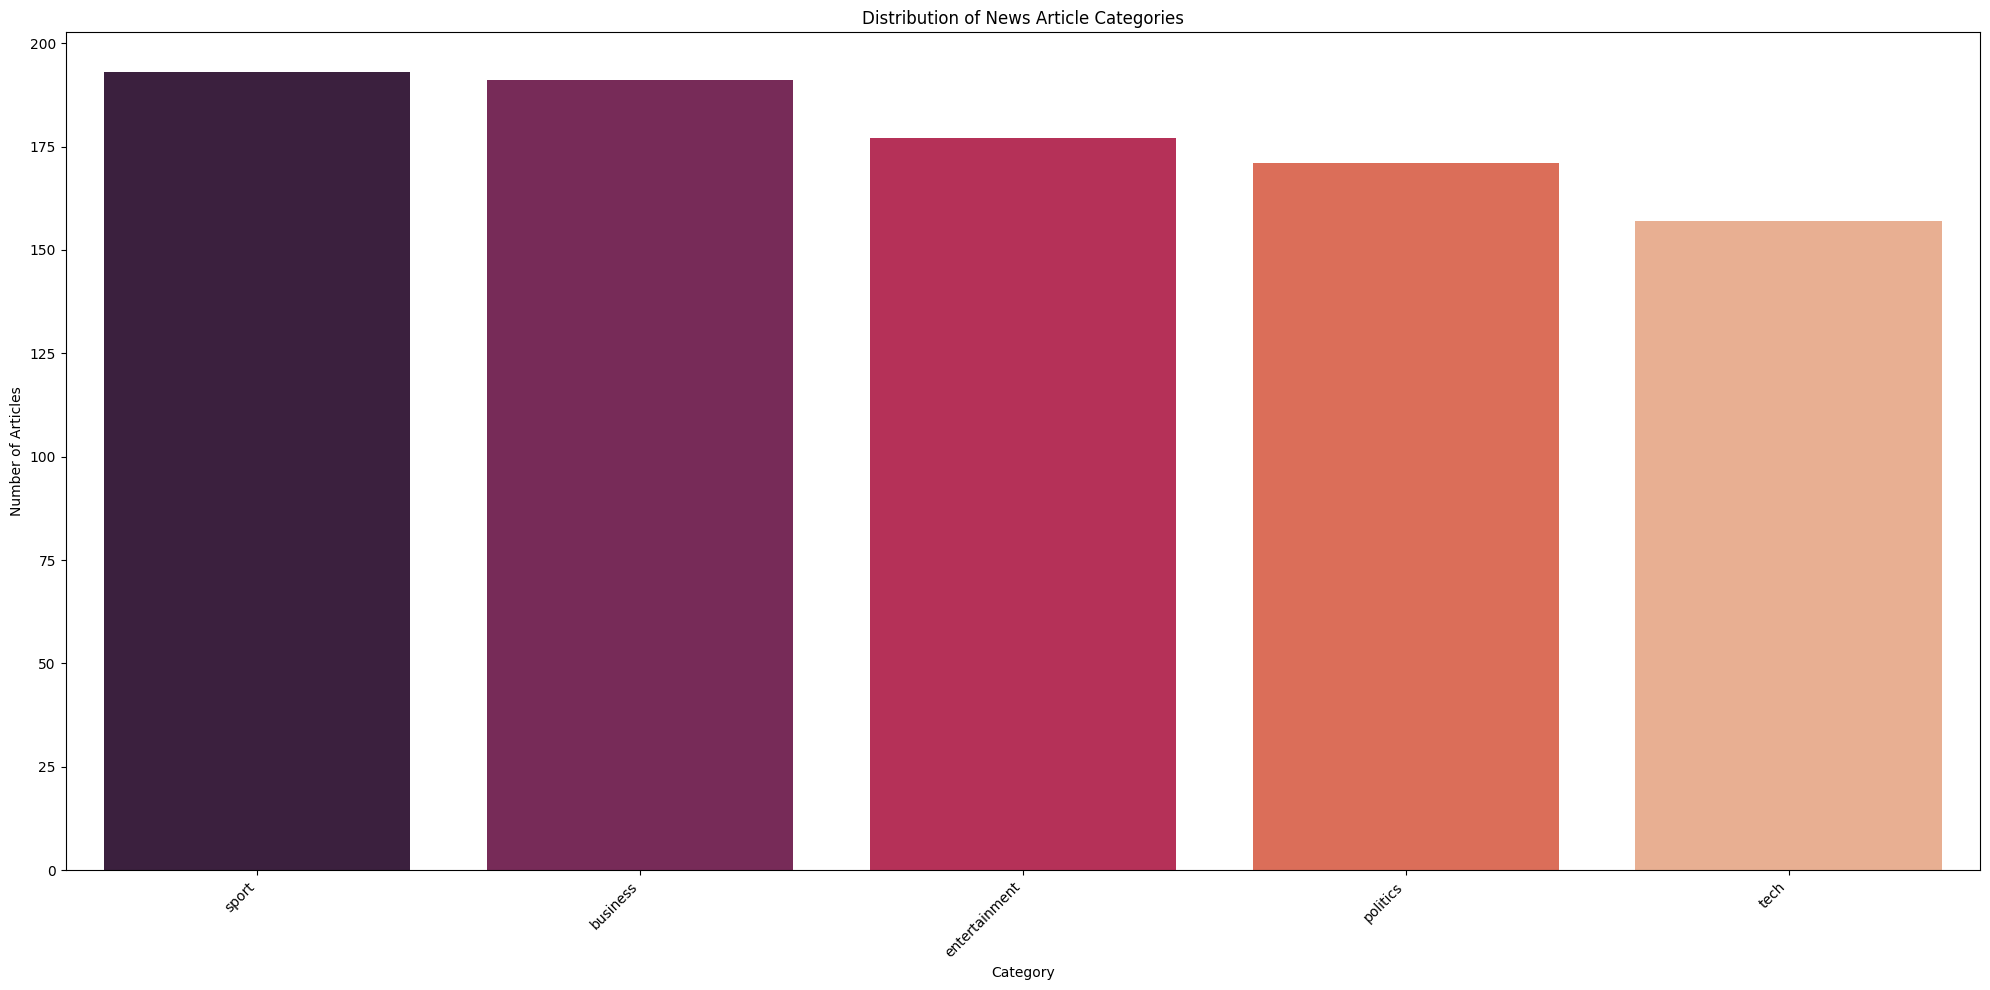

In [ ]:
plt.figure(figsize=(20, 10))

sns.countplot(
    x='category',
    data=train,
    palette='rocket', 
    order=train['category'].value_counts().index
)

plt.title('Distribution of News Article Categories')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Based on the bar chart output:

- The dataset is relatively well-balanced, with all five categories having a high number of articles, around 170 or more.
- Business and Sport is the second most frequent, with around 180 articles.
- Entertainment follows closely with about 170 articles.
- Politics and Tech have the fewest, with Politics around 150 and Tech around 150 articles.

The balance across categories is a positive finding, as it suggests the model will not be heavily biased toward predicting features of a single dominant category.

**Frequent Words Visualization (Word Clouds)**

This final section generates Word Clouds for both the original 'News Articles' and the 'Summaries' for each category. The size of a word in a word cloud indicates its frequency in the text data after cleaning (removing punctuation, numbers, stopwords, etc.).

- A helper function, `clean_text_for_wordcloud`, is defined to preprocess the text: it lowercases text, removes punctuation, numbers, extra spaces, and common stopwords.
- The cleaned text from all articles/summaries within a single category is concatenated into one large string.
- The WordCloud library then uses the frequency of words in these concatenated strings to determine font size, visually representing the most frequent and important terms for that category.


Generating Word Clouds for News Articles by Category...


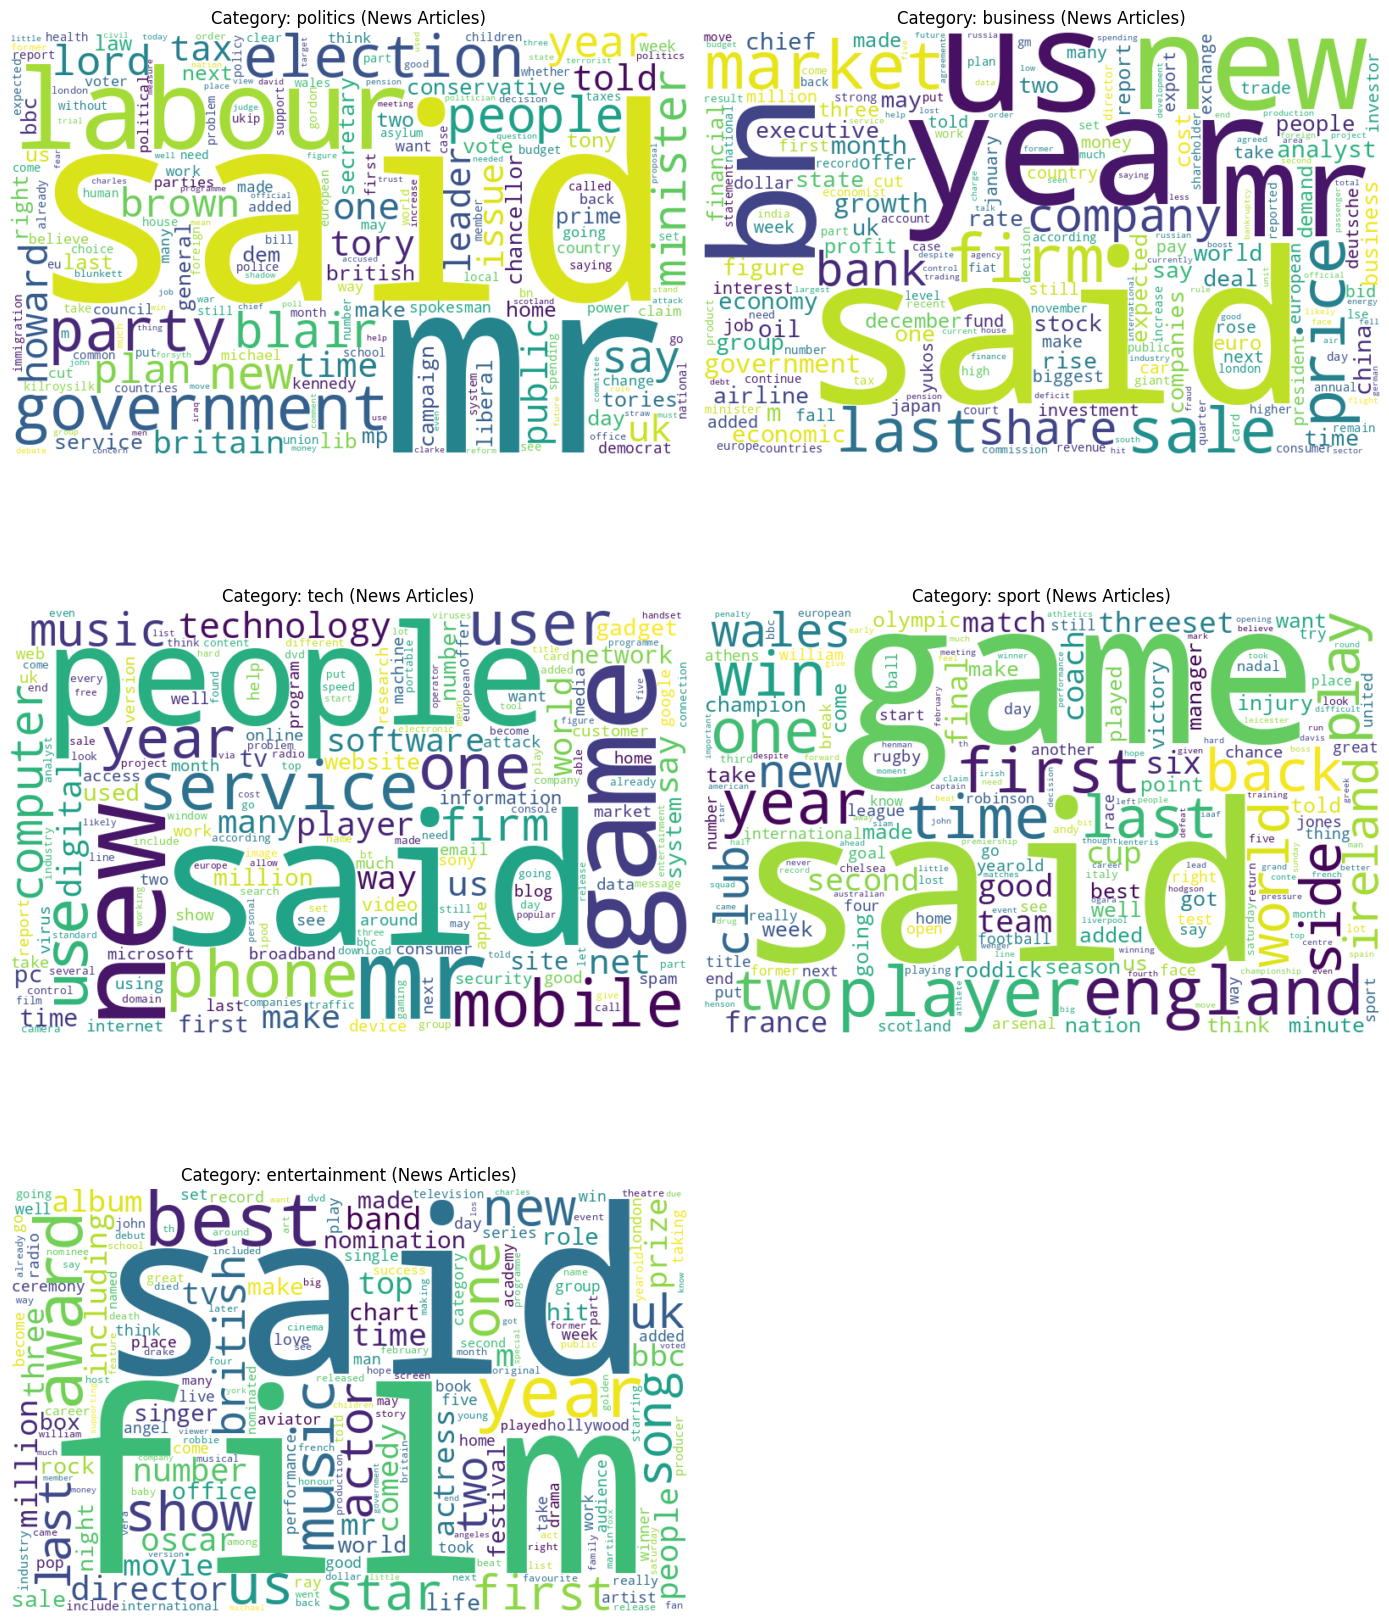

In [ ]:
def clean_text_for_wordcloud(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in STOPWORDS and len(word) > 1]
    return " ".join(words)

train_v = train.copy()
train_v['cleaned_articles'] = train_v['News Articles'].apply(clean_text_for_wordcloud)

category_article_texts = {}
for category in train_v['category'].unique():
    all_text_in_category = " ".join(train_v[train_v['category'] == category]['cleaned_articles'])
    category_article_texts[category] = all_text_in_category

num_categories = len(category_article_texts)
if num_categories == 0:
    print("No categories with text content from 'News Articles' found for word cloud generation.")
else:
    cols = 2
    rows = (num_categories + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 6))
    axes = axes.flatten()

    print("\nGenerating Word Clouds for News Articles by Category...")
    for i, (category, text) in enumerate(category_article_texts.items()):
        if not text.strip():
            print(f"Skipping word cloud for empty or processed category text: {category}")
            continue

        wordcloud = WordCloud(width=800, height=500,
                              background_color='white',
                              colormap='viridis',
                              min_font_size=10,
                              collocations=False
                             ).generate(text)

        ax = axes[i]
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.set_title(f'Category: {category} (News Articles)', fontsize=12)
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

**News Articles**

The picture shows the most frequent words in the full news articles for each category.

- Sport: Words like 'england', 'team', 'win', 'cup', 'play', and 'game' dominate, suggesting coverage of UK sports (especially football/rugby) and major competitions.
- Business: 'said', 'us', 'company', 'market', 'sale', 'government', and 'year' are prominent. This reflects reporting on corporate activity, financial markets, and the US economy.
- Politics: 'government', 'mr', 'blair', 'said', 'minister', 'labour', and 'conservative' stand out. This strongly suggests the articles focus on UK politics, specifically featuring former Prime Minister Tony Blair.
- Tech: 'said', 'new', 'people', 'microsoft', 'phone', 'game', and 'service' are the largest. This indicates a focus on product launches, mobile technology, gaming, and major tech companies like Microsoft.
- Entertainment: 'said', 'film', 'music', 'oscar', 'actor', 'actress', and 'uk' are most frequent, clearly showing a focus on cinema (especially awards like the Oscars), music, and British entertainment.

**Frequency words on articles of each categories**


Generating Word Clouds for Summaries by Category...


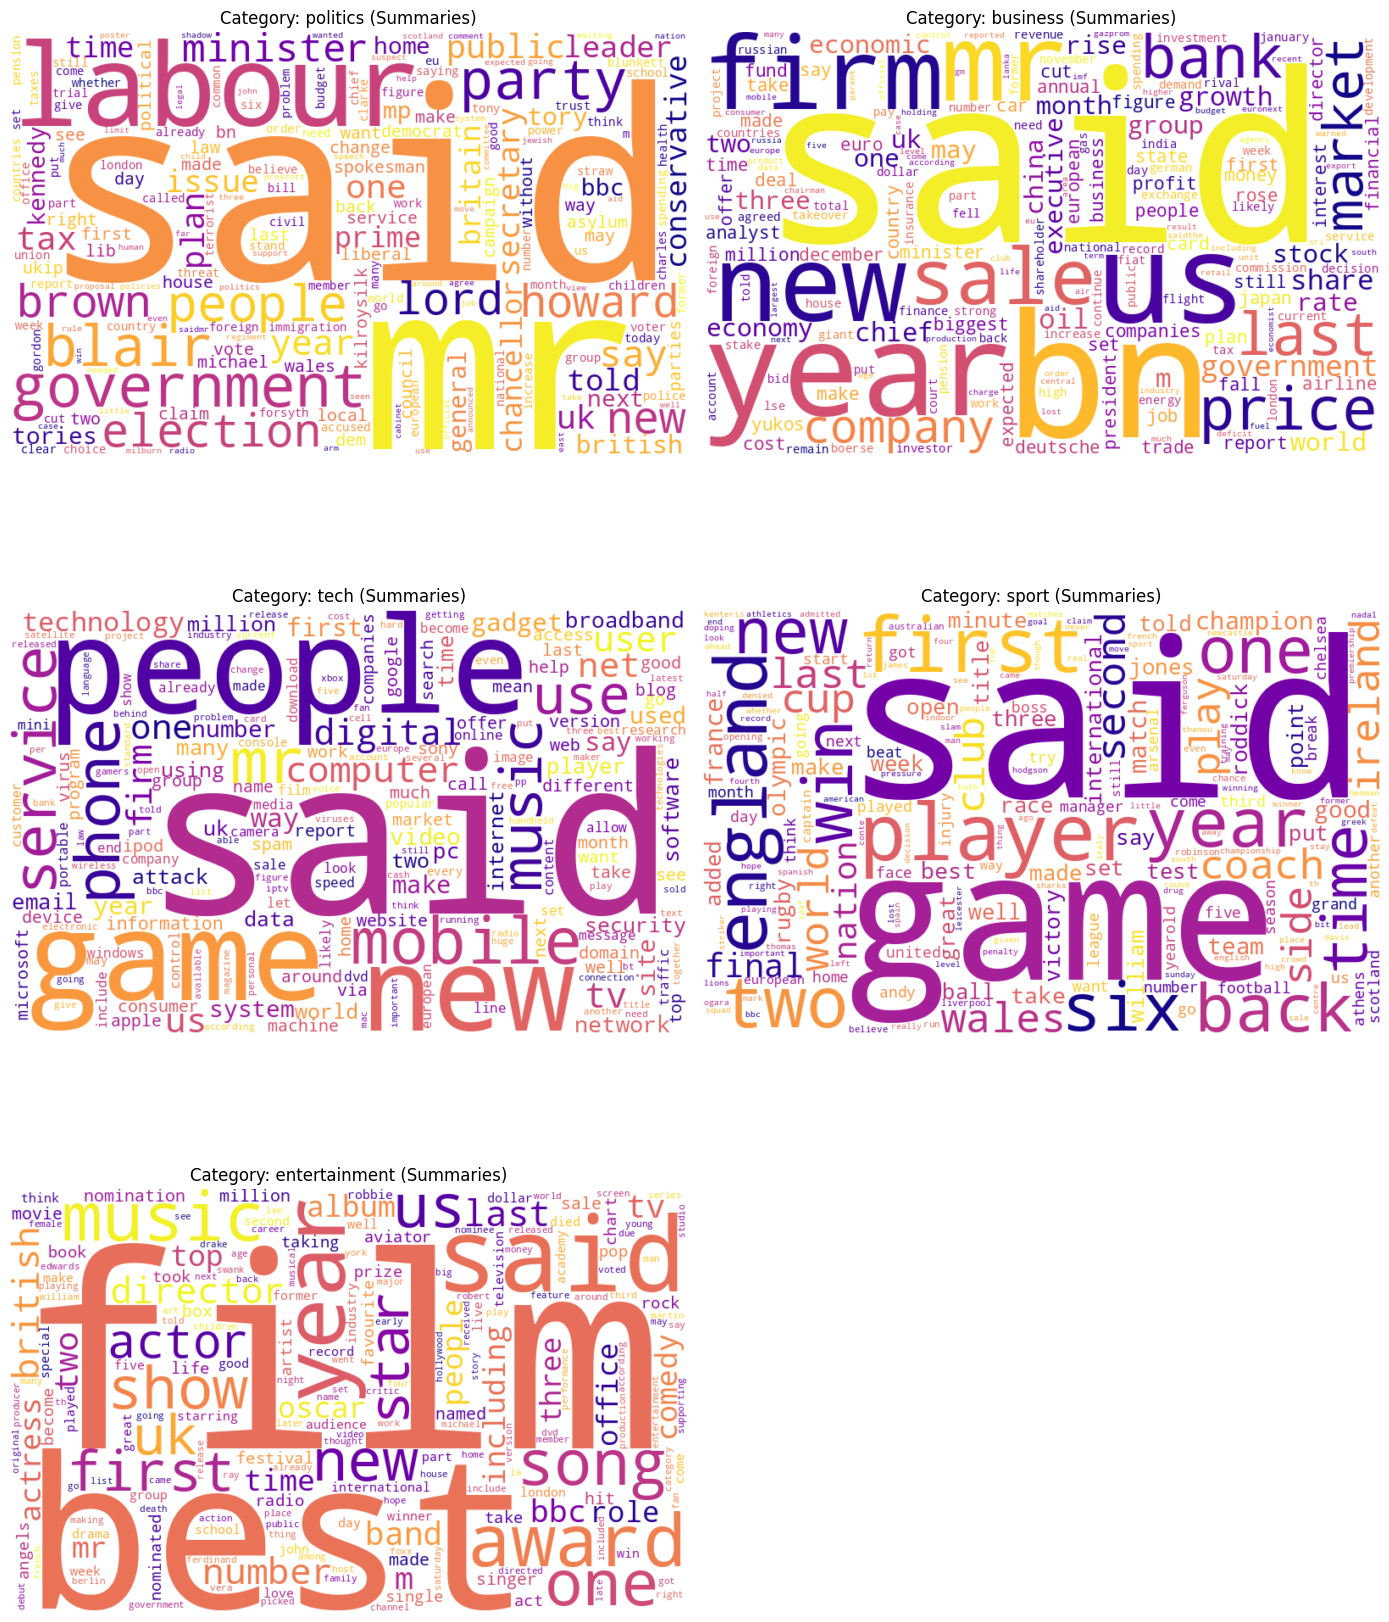

In [22]:
train_v = train.copy()
train_v['cleaned_summaries'] = train['Summaries'].apply(clean_text_for_wordcloud)

category_summary_texts = {}
for category in train_v['category'].unique():
    all_text_in_category = " ".join(train_v[train_v['category'] == category]['cleaned_summaries'])
    category_summary_texts[category] = all_text_in_category

num_categories_sum = len(category_summary_texts)
if num_categories_sum > 0:
    cols_sum = 2
    rows_sum = (num_categories_sum + cols_sum - 1) // cols_sum
    fig_sum, axes_sum = plt.subplots(rows_sum, cols_sum, figsize=(cols_sum * 7, rows_sum * 6))
    axes_sum = axes_sum.flatten()
    print("\nGenerating Word Clouds for Summaries by Category...")
    for i, (category, text) in enumerate(category_summary_texts.items()):
        if not text.strip():
            print(f"Skipping summary word cloud for empty category text: {category}")
            continue

        wordcloud_sum = WordCloud(width=800, height=500,
                                  background_color='white',
                                  colormap='plasma',
                                  min_font_size=10,
                                  collocations=False
                                 ).generate(text)

        ax_sum = axes_sum[i]
        ax_sum.imshow(wordcloud_sum, interpolation='bilinear')
        ax_sum.set_title(f'Category: {category} (Summaries)', fontsize=12)
        ax_sum.axis('off')
    for j in range(i + 1, len(axes_sum)):
        fig_sum.delaxes(axes_sum[j])

    plt.tight_layout()
    plt.show()

The image shows the most frequent words in the summaries for each category.

**Key Observation:** Across all categories, the word 'said' is disproportionately larger in the summaries compared to the full articles. This suggests that summarization techniques heavily retain reporting verbs, as they are essential for conveying who delivered key information or statements. The summaries are generally much shorter, making a few common words more dominant.

**Category-Specific Differences:**

- Sport (Summaries): The core themes remain ('cup', 'win', 'year', 'england'), but 'said' is much larger.
- Business (Summaries): Similar to articles ('company', 'year', 'us', 'market'), with 'said' as the largest word.
- Politics (Summaries): 'mr', 'blair', 'government', and 'people' are still key, confirming the UK focus, but 'said' is massive.
- Tech (Summaries): Words like 'new', 'said', 'game', and 'service' remain, indicating the focus on new products and services.
- Entertainment (Summaries): 'film', 'music', 'oscar', and 'actor' are still defining terms, heavily anchored by the very frequent use of 'said'.

# Text Cleaning

The `clean_text` function executes a series of Normalization and Noise Reduction steps in a specific order.

**A. Normalization Techniques**

Normalization standardizes word representations, ensuring that variations of the same word are treated as a single token by the model, which reduces the overall vocabulary size and prevents sparsity.

- **Contraction Expansion:** The first step uses `contractions.fix()` to expand shortened forms (e.g., "we'll" becomes "we will"). This is vital for Semantic Preservation, as it ensures the full meaning is available before tokenization and prevents the model from treating the contracted form as a separate or incomplete word.

By applying the `clean_text` function to the raw text columns (News Articles and Summaries) in both the training and testing datasets, the code is performing Feature Engineering. It transforms the raw text data into a new set of input features (cleaned_articles) and target features (`cleaned_summaries`) suitable for machine learning algorithms. It is crucial to apply the exact same cleaning process to both the training and testing sets to prevent Data Leakage and ensure that the model is evaluated fairly on normalized data.

In [ ]:
def clean_text(text):
    """
    Cleans text by expanding contractions, lowercasing, removing punctuation,
    digits, extra spaces, and stopwords. Handles non-string inputs gracefully.
    """
    if not isinstance(text, str):
        return ""

    text = contractions.fix(text)

    return text

print("Cleaning 'News Articles' and 'Summaries' text columns...")

train['News Articles'] = train['News Articles'].apply(clean_text)
train['Summaries'] = train['Summaries'].apply(clean_text)
test['News Articles'] = test['News Articles'].apply(clean_text)
test['Summaries'] = test['Summaries'].apply(clean_text)
print("Text cleaning complete.")

Cleaning 'News Articles' and 'Summaries' text columns...
Text cleaning complete.


# Model Training (TextRank)

## Extractive Summarization using TextRank

Extractive Summarization using the TextRank algorithm, which is a powerful, unsupervised machine learning technique derived from Google's famous PageRank algorithm. Instead of generating new sentences (Abstractive Summarization), TextRank selects the most important existing sentences from the document to form the summary.

**The TextRank Algorithm: A Graph-Based Approach**

Rank models a document as a graph where the nodes represent the sentences and the edges represent the semantic relationship (similarity) between those sentences. The goal is to find the sentences that are most central to the document's overall theme.

**A. Tokenization and Sentence Vectorization**

- **Sentence Tokenization:** The process begins by splitting the input text into individual sentences using the nltk.sent_tokenize function. Each sentence becomes a potential node in the graph.
- **TF-IDF Vectorization:** Each sentence is then converted into a numerical vector using Term Frequency-Inverse Document Frequency (TF-IDF). The key concept here is that TF-IDF assigns a higher weight to words that are frequent in a specific sentence (High Term Frequency - TF) but rare across the entire set of sentences in the article (High Inverse Document Frequency - IDF). This effectively identifies the distinguishing keywords of each sentence.

**B. Similarity Matrix and Graph Construction**

- **Cosine Similarity:** The core of the model is creating a Similarity Matrix. This matrix is calculated by finding the cosine similarity between every pair of sentence vectors generated by TF-IDF. Cosine similarity measures the cosine of the angle between two vectors and is a standard way to determine how semantically close two text segments are, regardless of their length. A higher cosine value (closer to 1) means the sentences share more important vocabulary, indicating high conceptual overlap.
- **Graph Generation:** The similarity matrix is then transformed into a network graph using the networkx library. Sentences are the nodes, and the similarity scores become the weighted edges connecting them. Highly similar sentences are strongly connected.

**C. Sentence Ranking via PageRank**

- **PageRank Application:** The fundamental innovation of TextRank is applying the PageRank algorithm to this sentence graph. PageRank, originally used to rank web pages, works on the principle of "vote counting": a sentence is considered important if it is linked to by many other important sentences. In the context of TextRank, this translates to a sentence's importance (rank) is boosted by its similarity (weighted edge) to many other important sentences. This iterative ranking process identifies the sentences that are central hubs of information in the document.
- **Sentence Selection:** After PageRank converges, the sentences are sorted by their final rank score. The top $N$ sentences, as specified by the num_sentences parameter, are selected.

**D. Summary Output Ordering**

Although the sentences are ranked by importance, they are reordered back into their original sequential appearance in the source article. This step ensures the final summary maintains logical flow and coherence for the reader. The result is an extractive summary composed solely of the most important, original sentences.

In [ ]:
def summarize_text_textrank(text, num_sentences=2):
    """
    Generates a summary of a given text using the TextRank algorithm.

    The algorithm works as follows:
    1. Tokenize the input text into individual sentences.
    2. Create a similarity matrix between all sentence pairs.
       This is done by converting sentences into TF-IDF vectors
       and calculating the cosine similarity.
    3. Build a graph where each sentence is a node and the edges
       are weighted by the similarity scores.
    4. Use the PageRank algorithm (TextRank) on the graph to
       determine the importance of each sentence.
    5. Select the top `num_sentences` with the highest TextRank scores
       to form the summary.

    Args:
        text (str): The input text to be summarized.
        num_sentences (int): The number of sentences to include in the summary.

    Returns:
        str: The generated summary.
    """
    sentences = nltk.sent_tokenize(text)
    
    if len(sentences) <= num_sentences:
        return " ".join(sentences)

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(sentences)
    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

    nx_graph = nx.from_numpy_array(similarity_matrix)

    scores = nx.pagerank(nx_graph)

    ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)
    summary_sentences = [sentence for score, sentence in ranked_sentences[:num_sentences]]

    summary_sentences.sort(key=lambda s: sentences.index(s))
    return " ".join(summary_sentences)

print("\nApplying TextRank algorithm to generate summaries...")

train['textrank_summary'] = train['News Articles'].apply(summarize_text_textrank)

print("TextRank summarization complete.")
print("-" * 50)

print("\n--- Example of TextRank Summary vs. Original Summary ---")
example_index = 1
original_article = train['News Articles'].iloc[example_index]
original_summary = train['Summaries'].iloc[example_index]
textrank_summary = train['textrank_summary'].iloc[example_index]

print(f"Original Article:\n{original_article}")
print(f"\nOriginal Summary:\n{original_summary}")
print(f"\nTextRank Generated Summary:\n{textrank_summary}")


Applying TextRank algorithm to generate summaries...
TextRank summarization complete.
--------------------------------------------------

--- Example of TextRank Summary vs. Original Summary ---
Original Article:
Defection timed to hit tax pledge

With impeccable and precisely-calculated timing, Tory defector Robert Jackson and his new Labour bosses have attempted to overshadow Michael Howard's latest announcement on taxation and spending.

With just about everyone in Westminster now working towards a May general election, Mr Howard is eager to map out some clear and distinctive policies aimed at finally shifting the Tories' resolutely depressing poll showings. The big idea is his £35bn savings on waste and bureaucracy which Mr Howard has pledged to plough back into public services and tax cuts. And it was virtually certain his pledge on tax cuts was meant to be the core message from his interview on the BBC One's Breakfast with Frost programme. He and his shadow Chancellor Oliver Let

## Similarity Matrix Validation

The `calculate_similarity_matrix_from_df` function demonstrates the transformation of raw text into a numerical matrix that captures the semantic relationships between every pair of sentences in a document. This matrix ultimately defines the weighted edges of the TextRank graph.

**1. Document Preparation and Tokenization**

The initial steps are dedicated to preparing the input text for numerical processing:

- Extraction: The code first extracts the article text from the Pandas DataFrame. This step ensures the model operates on the correct data instance (`article_text`).
- Sentence Tokenization: The text is split into individual sentences using `nltk.sent_tokenize`. In graph theory terms, each of these resulting sentences will become a node in the TextRank network.

**2. Feature Vectorization using TF-IDF**

Sentences, being text, cannot be directly processed by mathematical algorithms. They must be converted into numerical vectors, a process known as feature vectorization or word embedding.

- Bag-of-Words Model: The TF-IDF Vectorizer operates on a conceptual framework known as the Bag-of-Words (BoW) model, where the order of words is ignored, and only the frequency of words matters.
- TF-IDF Weighting: The TfidfVectorizer assigns a weight to every word in every sentence. This weight is determined by:
    - Term Frequency (TF): How often a word appears in the current sentence.
    - Inverse Document Frequency (IDF): The inverse measure of how often a word appears across all sentences in the article.
    - Rationale: The combined $TF-IDF$ weight prioritizes words that are frequently occurring within a specific sentence but rare across the document as a whole. This is essential because it identifies the words that uniquely characterize the sentence's content, allowing the comparison step to focus on substantive, topic-defining terms rather than common stop words.

**3. Quantifying Relationships with Cosine Similarity**

The final step uses the vectorized sentence representations to quantify the relationships between them, creating the similarity matrix.

- Dimensionality: The resulting $TF-IDF$ matrix has a shape where the number of rows equals the number of sentences, and the number of columns equals the number of unique words (features) found in the entire set of sentences.
- Cosine Similarity Metric: The cosine_similarity function measures the cosine of the angle between two $TF-IDF$ sentence vectors in the high-dimensional feature space. This metric determines semantic similarity based purely on the orientation of the vectors, disregarding their magnitude (sentence length). A similarity score close to 1 indicates the sentences share a significant amount of weighted vocabulary, meaning they are highly similar in content.
    - The Matrix's Role: The resulting similarity matrix is symmetric and has diagonal values of 1.0 (as a sentence is perfectly similar to itself). The off-diagonal values represent the weighted edges of the TextRank graph, indicating how strongly two sentences are connected based on shared content.

In [ ]:
def calculate_similarity_matrix_from_df(dataframe, index):
    """
    Illustrates how the TextRank model gets the sentence similarity matrix
    by taking a text from a Pandas DataFrame.
    
    The process involves two main steps:
    1.  Convert sentences into numerical vectors using TF-IDF.
    2.  Calculate the cosine similarity between each of these vectors.

    Args:
        dataframe (pd.DataFrame): The DataFrame containing the text.
        index (int): The index of the article to use from the DataFrame.
    
    Returns:
        tuple: A tuple containing the list of sentences and the similarity matrix.
    """
    article_text = dataframe.iloc[index, dataframe.columns.get_loc('News Articles')]

    sentences = nltk.sent_tokenize(article_text)
    
    if len(sentences) < 2:
        print("Not enough sentences to form a similarity matrix.")
        return sentences, None

    print(f"--- Original Article from train.iloc[{index}] ---")
    print(article_text)
    print("-" * 30)

    print("--- Tokenized Sentences ---")
    for i, sentence in enumerate(sentences):
        print(f"Sentence {i+1}: {sentence}")
    print("-" * 30)

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(sentences)
    
    print("--- TF-IDF Matrix Shape ---")
    print(f"The matrix has {tfidf_matrix.shape[0]} rows (sentences) and {tfidf_matrix.shape[1]} columns (unique words/features).")
    print("-" * 30)
    
    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

    return sentences, similarity_matrix

article_index_to_use = 1

sentences, sim_matrix = calculate_similarity_matrix_from_df(train, article_index_to_use)

if sim_matrix is not None:
    print("--- Resulting Similarity Matrix ---")
    print(np.around(sim_matrix, decimals=2))

--- Original Article from train.iloc[1] ---
Defection timed to hit tax pledge

With impeccable and precisely-calculated timing, Tory defector Robert Jackson and his new Labour bosses have attempted to overshadow Michael Howard's latest announcement on taxation and spending.

With just about everyone in Westminster now working towards a May general election, Mr Howard is eager to map out some clear and distinctive policies aimed at finally shifting the Tories' resolutely depressing poll showings. The big idea is his £35bn savings on waste and bureaucracy which Mr Howard has pledged to plough back into public services and tax cuts. And it was virtually certain his pledge on tax cuts was meant to be the core message from his interview on the BBC One's Breakfast with Frost programme. He and his shadow Chancellor Oliver Letwin have been edging towards an announcement on this front for some months now, but without any concrete pledges. But Mr Howard announced that, of the £35bn he has earmar

## Algorithms Explaination

**How the algorithm worked?**

The core of this code is the function `summarize_text_textrank`, which implements the algorithm, and `visualize_textrank_pipeline`, which deconstructs the underlying Graph-Based Ranking theory for clarity.

**1. The TextRank Algorithm: From Text to Rank**

The `summarize_text_textrank` function follows a rigid sequence of steps based on Graph Theory and Vector Space Modeling to identify the most significant sentences:

- **Node Definition (Tokenization):** The raw text is first segmented into individual sentences using `nltk.sent_tokenize`. Each sentence represents a node in the graph structure.
- **Edge Weight Calculation (Vectorization and Similarity):**
    - Sentences are converted into numerical TF-IDF vectors. The TF-IDF concept weights words by their importance - high frequency within a sentence, low frequency across the document—ensuring that topic-specific words drive similarity.
    - Cosine Similarity is computed between every pair of sentence vectors, resulting in the Similarity Matrix. The values in this matrix are the weighted edges of the graph, quantifying the degree of semantic overlap between sentences.
- **Ranking (PageRank Application):**
    - The similarity matrix is transformed into a NetworkX graph (`nx_graph`).
    - The PageRank algorithm (`nx.pagerank`) is applied to this graph. PageRank operates on the principle of iterative convergence: a sentence's final score (rank) is determined by the sum of scores of all sentences linking to it, weighted by the strength of the links (similarity). This effectively identifies sentences that are central hubs of information in the document.
- **Extractive Summary Generation:** The sentences are sorted by their PageRank scores, and the top $N$ sentences (defined by `num_sentences`) are selected. They are then re-sorted back into their original document order to maintain narrative coherence.

**2. The Visualization and Verification Pipeline**

The `visualize_textrank_pipeline` and accompanying demonstration code provide model introspection, a crucial aspect of transparent machine learning. It directly illustrates the transformation stages mandated by the TextRank theory.

- Block: Sentences (Nodes): Confirms the correct granularity (sentence-level) of the input, defining the nodes of the graph.
- Block: Similarity Matrix (Edges): Explicitly shows the output of the Cosine Similarity calculation. The matrix numerically proves that sentences discussing related concepts (e.g., injuries, players) have higher similarity scores, thus justifying the strong connection (edge) between those nodes.
- Block: Sentence Rankings (PageRank Scores): This is the ultimate output of the algorithm. It clearly lists which sentences received the highest influence scores. The high-scoring sentences (like Sentence 8 and 5 in the example) are designated as the most important contributors to the article's core theme, providing a direct justification for the final summary content.
- Block: Summary: The final output confirms that the summary is generated by selecting the highest-ranking sentences and presenting them in their original order, thereby completing the extractive process.

**3. Application and Comparison**

The code applies the `summarize_text_textrank` function to the 'News Articles' column in the training data, creating a new `textrank_summary` column. The verification step, comparing the TextRank Generated Summary against the Original Summary (human-written reference), serves as an initial, qualitative check of the model's performance before formal metric-based evaluation. This comparison visually confirms that the extractive method successfully captures key entities and factual statements.

In [ ]:
def summarize_text_textrank(text, num_sentences=2):
    """
    Generates a summary of a given text using the TextRank algorithm.
    This function returns the final summary string.
    """
    sentences = nltk.sent_tokenize(text)
    
    if len(sentences) <= num_sentences:
        return " ".join(sentences)

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(sentences)
    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

    nx_graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(nx_graph)

    ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)
    summary_sentences = [sentence for score, sentence in ranked_sentences[:num_sentences]]

    summary_sentences.sort(key=lambda s: sentences.index(s))
    return " ".join(summary_sentences)

def get_textrank_details(text, num_sentences=2):
    """
    Runs the TextRank algorithm and returns intermediate details for visualization.
    """
    sentences = nltk.sent_tokenize(text)
    
    if len(sentences) <= num_sentences:
        return sentences, {}, {}, " ".join(sentences), sentences

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(sentences)
    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

    nx_graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(nx_graph)

    ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)
    summary_sentences_list = [sentence for score, sentence in ranked_sentences[:num_sentences]]
    summary_sentences_list.sort(key=lambda s: sentences.index(s))
    final_summary_text = " ".join(summary_sentences_list)

    return sentences, similarity_matrix, scores, final_summary_text, summary_sentences_list


def visualize_textrank_pipeline(original_article, original_sentences, similarity_matrix, scores, final_summary):
    """
    Prints a detailed step-by-step visualization of the TextRank process,
    following the block diagram flow.
    """
    print("\n" + "="*80)
    print("                TextRank Algorithm Visualization Pipeline")
    print("="*80)

    print("\n--- Block: Text ---")
    print(original_article)
    
    print("\n--- Block: Sentences ---")
    for i, sentence in enumerate(original_sentences):
        print(f"[{i+1}] {sentence}")

    print("\n--- Block: Similarity Matrix ---")
    print("Each value represents the cosine similarity between two sentences.")
    if similarity_matrix is not None:
        print(np.around(similarity_matrix, decimals=2))
    else:
        print("Not applicable (too few sentences).")

    print("\n--- Block: Sentence Rankings (via PageRank) ---")
    print("Sentences with higher scores are considered more important.")
    if scores is not None:
        sorted_scores = sorted(scores.items(), key=lambda item: item[1], reverse=True)
        for sentence_index, score in sorted_scores:
            print(f"[{sentence_index+1}] (Score: {score:.4f}): {original_sentences[sentence_index]}")
    else:
        print("Not applicable (too few sentences).")

    print("\n--- Block: Summary ---")
    print("The final summary is created by combining the top-ranked sentences.")
    print(final_summary)

    print("="*80)


print("\nApplying TextRank algorithm to generate summaries...")
train['textrank_summary'] = train['News Articles'].apply(summarize_text_textrank)
print("TextRank summarization complete.")
print("-" * 50)

print("\n--- Example of TextRank Summary vs. Original Summary ---")
example_index = 1
original_article = train['News Articles'].iloc[example_index]
original_summary = train['Summaries'].iloc[example_index]
textrank_summary = train['textrank_summary'].iloc[example_index]

print(f"Original Article:\n{original_article}")
print(f"\nOriginal Summary:\n{original_summary}")
print(f"\nTextRank Generated Summary:\n{textrank_summary}")

print("-" * 50)

print("\n--- TextRank Model Visualization ---")
sample_article_for_viz = train['News Articles'].iloc[1]
sentences, similarity_matrix, scores, final_summary, _ = get_textrank_details(sample_article_for_viz, num_sentences=2)

visualize_textrank_pipeline(
    original_article=sample_article_for_viz,
    original_sentences=sentences,
    similarity_matrix=similarity_matrix,
    scores=scores,
    final_summary=final_summary
)


Applying TextRank algorithm to generate summaries...
TextRank summarization complete.
--------------------------------------------------

--- Example of TextRank Summary vs. Original Summary ---
Original Article:
Defection timed to hit tax pledge

With impeccable and precisely-calculated timing, Tory defector Robert Jackson and his new Labour bosses have attempted to overshadow Michael Howard's latest announcement on taxation and spending.

With just about everyone in Westminster now working towards a May general election, Mr Howard is eager to map out some clear and distinctive policies aimed at finally shifting the Tories' resolutely depressing poll showings. The big idea is his £35bn savings on waste and bureaucracy which Mr Howard has pledged to plough back into public services and tax cuts. And it was virtually certain his pledge on tax cuts was meant to be the core message from his interview on the BBC One's Breakfast with Frost programme. He and his shadow Chancellor Oliver Let

## Different Hyperparameters Impacts

**TextRank Hyperparameters**

The key hyperparameters for the TextRank summarization model are primarily derived from two stages: the Extraction Stage and the Text Representation Stage (specifically, the TF-IDF Vectorization).

**1. Extraction Stage Hyperparameter**

This parameter governs the final output length of the extractive summary.

`num_sentences` (Summary Length)
- Meaning: This is a required parameter that specifies the maximum number of top-ranked sentences to be included in the final summary.
- Impact: It directly controls the compression rate. A smaller number of sentences results in a shorter, more concise summary, while a larger number results in higher content coverage (recall) but potentially lower precision and coherence.

**2. Text Representation Hyperparameters**

These parameters are passed to the `TfidfVectorizer` and influence how sentences are converted into numerical vectors, which ultimately determines the sentence similarity scores (the graph's edge weights).

`ngram_range` (Feature Granularity)
- Meaning: This defines the lower and upper boundary of the $N$-grams (word sequences) to be included as features in the TF-IDF matrix. For example, `(1, 1)` includes single words (unigrams), and `(1, 2)` includes both unigrams and two-word sequences (bigrams).
- Impact: Including higher N-grams helps capture local semantic relationships and meaningful phrases (e.g., "market volatility"), potentially leading to more accurate similarity calculations than just relying on single words.

`min_df` (Minimum Document Frequency)
- Meaning: Specifies the minimum number of documents (sentences, in this case) a term must appear in to be included in the vocabulary.
- Impact: Setting `min_df` greater than 1 acts as a noise filter, removing very rare words (often typos or unique, non-topical entities) that only appear once. This ensures the TF-IDF matrix focuses on terms that contribute to the global connection between multiple sentences.

`max_df` (Maximum Document Frequency)
- Meaning: Specifies the maximum proportion or count of documents (sentences) a term can appear in to be included in the vocabulary.
- Impact: Typically used to filter out extremely common words that are not included in the standard `stop_words` list. These common words (like names of months or generic corporate terms) offer little discriminative value, so removing them can improve the focus of the similarity calculation.

`stop_words` (Token Filtering)
- Meaning: A list of words (e.g., 'the', 'a', 'is') that will be ignored when building the vocabulary.
- Impact: Filtering common words, as shown by the use of 'english', ensures the TF-IDF weights are assigned to content-bearing terms, making the similarity matrix a better reflection of semantic overlap.

**3. Graph Ranking Hyperparameters (Implicit)**

While not explicitly passed to the main wrapper function in the code, the PageRank algorithm itself has key parameters that could be tuned via `networkx.pagerank()`:

`alpha` (Damping Factor)
- Meaning: In PageRank, this is the probability (usually set to 0.85 by default) that a node (sentence) will pass its importance score along its links (edges) versus a random jump to any other node.
- Impact: It controls the influence of a node's local network (strong links) versus the influence of the overall document.

`structure.max_iter` (Maximum Iterations):
- Meaning: The maximum number of iterations allowed for the `PageRank` score calculation to converge.
- Impact: Controls the calculation time and accuracy. The algorithm stops either when scores converge within a tolerance or after this many iterations.

**Experiment's Hyperparameters**

The core idea is to treat the TextRank summarizer as a system whose output quality depends not only on the PageRank algorithm but also on how the input text is represented and the desired output size.

**1. The Role of Hyperparameters**

The code systematically tests several hyperparameters, primarily affecting the feature vectorization stage (TF-IDF) and the extraction stage (sentence count).
- Extraction Hyperparameter (`num_sentences`): This parameter directly controls the compression rate of the extractive model. By comparing `num_sentences = 2` (default) against `num_sentences = 3` (More Sentences), the process explores the trade-off between conciseness and information coverage. More sentences usually increase recall (higher chance of overlapping with the reference) but decrease precision (more potentially redundant information).
- Vectorization Hyperparameters (TF-IDF): These parameters tune how the semantic space is constructed before similarity is calculated.
    - N-gram Range (`ngram_range`): Setting this to (`1, 2`) (Unigrams and Bigrams) means the TF-IDF vectorizer considers two-word sequences (bigrams, e.g., "Manchester United") as features, in addition to single words (unigrams). This captures local semantic relationships and potentially improves the accuracy of the similarity matrix by rewarding shared phrases, not just shared words.
    - Minimum Document Frequency (`min_df`): Setting `min_df=2` (Min Document Frequency of 2) acts as a noise filter. A word must appear in at least two separate sentences to be included in the vocabulary. This helps remove hapax legomena (words appearing only once), which are often typos or idiosyncratic terms that don't contribute meaningfully to establishing global semantic connections between sentences.

**2. Quantitative Evaluation**

Since extractive summarization aims to mimic a human-written summary (the "reference"), its quality must be measured by the degree of content overlap. The code uses two major classes of NLP evaluation metrics: ROUGE and BLEU.

**A. ROUGE (Recall-Oriented Understudy for Gisting Evaluation)**

- ROUGE is the standard metric for summarization. It is based on n-gram overlap between the generated summary and the reference summary, focusing on recall—how much of the content in the reference summary was captured by the generated one.
- ROUGE-N (`N=1, 2`): Measures the overlap of continuous N-grams.
- ROUGE-1 F1: Overlap of single words (unigrams). Primarily measures content word coverage.
- ROUGE-2 F1: Overlap of two-word sequences (bigrams). Primarily measures fluency and phrase integrity.
- ROUGE-L F1: Measures the Longest Common Subsequence (LCS). This focuses on the longest sequence of words found in both summaries in the same relative order, rewarding structural similarity without being penalized by gaps in the sequence. The F1-measure harmonically balances precision and recall for a comprehensive score.

**B. BLEU (Bilingual Evaluation Understudy)**

BLEU is a precision-focused metric, primarily designed for machine translation but adapted for summarization. It measures the precision of unigrams, bigrams, etc., against the reference, factoring in a Brevity Penalty to penalize summaries that are too short. A high BLEU score suggests the generated text is highly similar to the reference in terms of word choice and word sequence, effectively acting as a measure of faithfulness to the linguistic form of the reference.

In [ ]:
def summarize_text_textrank_with_params(text, num_sentences=2, **kwargs):
    """
    Generates a summary using TextRank, accepting TF-IDF parameters.
    """
    sentences = nltk.sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return " ".join(sentences)

    vectorizer = TfidfVectorizer(stop_words='english', **kwargs)
    tfidf_matrix = vectorizer.fit_transform(sentences)
    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

    nx_graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(nx_graph)

    ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)
    summary_sentences = [sentence for score, sentence in ranked_sentences[:num_sentences]]
    summary_sentences.sort(key=lambda s: sentences.index(s))
    
    return " ".join(summary_sentences)

def calculate_rouge(generated_summary, reference_summary):
    """
    Calculates ROUGE scores for a generated summary against a reference summary.
    """
    if rouge_scorer is None:
        return "ROUGE library not installed."
    
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(reference_summary, generated_summary)
    
    return {
        'rouge1_fmeasure': scores['rouge1'].fmeasure,
        'rouge2_fmeasure': scores['rouge2'].fmeasure,
        'rougeL_fmeasure': scores['rougeL'].fmeasure
    }

def calculate_bleu(generated_summary, reference_summary):
    """
    Calculates BLEU score for a generated summary against a reference summary.
    """
    if sentence_bleu is None:
        return "NLTK BLEU library not available."
    
    reference_tokens = [nltk.word_tokenize(reference_summary)]
    generated_tokens = nltk.word_tokenize(generated_summary)
    
    chencherry = SmoothingFunction()
    return sentence_bleu(reference_tokens, generated_tokens, smoothing_function=chencherry.method1)


def tune_textrank(article_text, original_summary):
    """
    Demonstrates tuning TextRank hyperparameters and evaluating results
    with BLEU and ROUGE scores.
    """
    print("\n" + "="*80)
    print("                Hyperparameter Tuning Demonstration with Evaluation")
    print("="*80)
    print(f"Original Article:\n{article_text}\n")
    print(f"Original (Reference) Summary:\n{original_summary}\n")
    
    param_configs = [
        {'name': 'Default Parameters', 'params': {'num_sentences': 2}},
        {'name': 'More Sentences', 'params': {'num_sentences': 3}},
        {'name': 'Unigrams and Bigrams', 'params': {'num_sentences': 2, 'ngram_range': (1, 2)}},
        {'name': 'Min Document Frequency of 2', 'params': {'num_sentences': 2, 'min_df': 2}}
    ]

    for config in param_configs:
        config_name = config['name']
        config_params = config['params']
        
        num_sentences_param = config_params.pop('num_sentences', 2)
        other_params = config_params
        
        generated_summary = summarize_text_textrank_with_params(
            text=article_text, 
            num_sentences=num_sentences_param, 
            **other_params
        )

        bleu_score = calculate_bleu(generated_summary, original_summary)
        rouge_scores = calculate_rouge(generated_summary, original_summary)
        
        print("-" * 80)
        print(f"Configuration: {config_name}")
        print(f"Generated Summary: {generated_summary}\n")
        print("Evaluation Scores:")
        if isinstance(bleu_score, float):
            print(f"  BLEU Score: {bleu_score:.4f}")
        else:
            print(f"  BLEU Score: {bleu_score}")
        
        if isinstance(rouge_scores, dict):
            print(f"  ROUGE-1 F1: {rouge_scores['rouge1_fmeasure']:.4f}")
            print(f"  ROUGE-2 F1: {rouge_scores['rouge2_fmeasure']:.4f}")
            print(f"  ROUGE-L F1: {rouge_scores['rougeL_fmeasure']:.4f}")
        else:
            print(f"  ROUGE Scores: {rouge_scores}")

    print("="*80)

print("\n--- TextRank Model Hyperparameter Tuning and Evaluation ---")
sample_article_for_tuning = train['News Articles'].iloc[1]
original_summary_for_tuning = train['Summaries'].iloc[1]

tune_textrank(sample_article_for_tuning, original_summary_for_tuning)


--- TextRank Model Hyperparameter Tuning and Evaluation ---

                Hyperparameter Tuning Demonstration with Evaluation
Original Article:
Defection timed to hit tax pledge

With impeccable and precisely-calculated timing, Tory defector Robert Jackson and his new Labour bosses have attempted to overshadow Michael Howard's latest announcement on taxation and spending.

With just about everyone in Westminster now working towards a May general election, Mr Howard is eager to map out some clear and distinctive policies aimed at finally shifting the Tories' resolutely depressing poll showings. The big idea is his £35bn savings on waste and bureaucracy which Mr Howard has pledged to plough back into public services and tax cuts. And it was virtually certain his pledge on tax cuts was meant to be the core message from his interview on the BBC One's Breakfast with Frost programme. He and his shadow Chancellor Oliver Letwin have been edging towards an announcement on this front for som

**Conclusion of Experiment**

The demonstration iterates through each configuration, generates a summary, and calculates the resulting BLEU and ROUGE scores. The purpose of this entire pipeline is to identify which set of parameters (e.g., more sentences, using bigrams, or filtering rare words) maximizes the evaluation metrics on the overall dataset, thereby finding the optimal setup for the TextRank model before its final deployment.

## Hyperparameter Tuning (Optuna)

**Automated Hyperparameter Tuning with Optuna**

Optuna is a hyperparameter optimization framework that uses a state-of-the-art sampling strategy called the Tree-structured Parzen Estimator (TPE) to intelligently explore the parameter space. Instead of exhaustively checking all combinations (grid search) or randomly sampling (random search), TPE learns from past trials to propose more promising parameter sets.

**1. The Optimization Objective**

**Maximization via Minimization**

The core conceptual challenge addressed here is using Optuna for a maximization problem (we want a higher BLEU score).
- Optuna's Default: Optuna is intrinsically designed to solve minimization problems by default, searching for the minimum value of an objective function.
- Negation Strategy: To adapt this for maximization, the objective function returns the negative of the desired metric (`-bleu_score`). Maximizing $f(x)$ is mathematically equivalent to minimizing $-f(x)$. Optuna finds the most negative score (the minimum), which corresponds to the highest positive BLEU score (the maximum).

**2. Defining the Search Space**

The objective function dictates the range and types of hyperparameters Optuna can explore for the TextRank model.

- num_sentences (Extraction): Explored as an integer using `trial.suggest_int`, ranging from 1 up to the total number of sentences in the article minus one. This ensures the summary is always a compressed version of the original text.
- min_df (TF-IDF Vectorization): Explored as an integer using `trial.suggest_int`, typically spanning from 1 to 3. This controls the vocabulary size by filtering out extremely rare words (which don't appear in at least $N$ sentences).
- ngram\_upper\_bound (TF-IDF Vectorization): Explored as a categorical parameter using `trial.suggest_categorical` (e.g., 1, 2, or 3). This dynamically sets the $n-gram$ range to $(1, N)$, determining whether the vectorizer includes unigrams, bigrams, and/or trigrams when calculating sentence similarity. Including higher $n-grams$ allows the model to capture more complex, multi-word phrases, potentially improving the representation of semantic meaning.

**3. Iterative Optimization Process**

The optimization process is executed by `study.optimize(objective, n_trials=20)`:
- Trial Generation: In each of the 20 trials, Optuna intelligently selects a unique combination of `num_sentences, min_df, and ngram_upper_bound` based on past results.
- Model Evaluation: The `TextRank` model is run with these trial parameters, and the BLEU score is calculated against the reference summary.
- Feedback Loop: The negative BLEU score is returned to the Optuna study, which updates its internal TPE model. This model uses the performance (the returned score) to guide the selection of parameters for the next trial, making the search much more efficient than blind sampling.

This process ensures the final, chosen TextRank model configuration is empirically validated to perform optimally on the given data, maximizing the alignment of the generated summaries with the human-written reference summaries, as measured by the BLEU metric.

In [ ]:
def summarize_text_textrank_with_params(text, num_sentences=2, **kwargs):
    """
    Generates a summary using TextRank, accepting TF-IDF parameters.
    """
    sentences = nltk.sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return " ".join(sentences)

    vectorizer = TfidfVectorizer(stop_words='english', **kwargs)
    tfidf_matrix = vectorizer.fit_transform(sentences)
    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

    nx_graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(nx_graph)

    ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)
    summary_sentences = [sentence for score, sentence in ranked_sentences[:num_sentences]]
    summary_sentences.sort(key=lambda s: sentences.index(s))
    
    return " ".join(summary_sentences)

def calculate_rouge(generated_summary, reference_summary):
    """
    Calculates ROUGE scores for a generated summary against a reference summary.
    """
    if rouge_scorer is None:
        return "ROUGE library not installed."
    
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(reference_summary, generated_summary)
    
    return {
        'rouge1_fmeasure': scores['rouge1'].fmeasure,
        'rouge2_fmeasure': scores['rouge2'].fmeasure,
        'rougeL_fmeasure': scores['rougeL'].fmeasure
    }

def calculate_bleu(generated_summary, reference_summary):
    """
    Calculates BLEU score for a generated summary against a reference summary.
    """
    if sentence_bleu is None:
        return "NLTK BLEU library not available."
    
    reference_tokens = [nltk.word_tokenize(reference_summary)]
    generated_tokens = nltk.word_tokenize(generated_summary)
    
    chencherry = SmoothingFunction()
    return sentence_bleu(reference_tokens, generated_tokens, smoothing_function=chencherry.method1)


def tune_textrank(article_text, original_summary):
    """
    Demonstrates hyperparameter tuning using Optuna to find the best
    parameters that maximize the BLEU score.
    """
    print("\n" + "="*80)
    print("                Optuna Hyperparameter Tuning Demonstration (BLEU Score)")
    print("="*80)
    print(f"Original Article:\n{article_text}\n")
    print(f"Original (Reference) Summary:\n{original_summary}\n")

    num_sentences_in_article = len(nltk.sent_tokenize(article_text))
    
    def objective(trial):
        num_sentences = trial.suggest_int('num_sentences', 1, num_sentences_in_article - 1)
        min_df = trial.suggest_int('min_df', 1, 3)
        ngram_upper_bound = trial.suggest_categorical('ngram_upper_bound', [1, 2, 3])
        ngram_range = (1, ngram_upper_bound)

        generated_summary = summarize_text_textrank_with_params(
            text=article_text,
            num_sentences=num_sentences,
            min_df=min_df,
            ngram_range=ngram_range
        )

        bleu_score = calculate_bleu(generated_summary, original_summary)
        
        return -bleu_score if isinstance(bleu_score, float) else 0.0

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20)
    
    print("-" * 80)
    print("Optuna Tuning Results:")
    print(f"Number of finished trials: {len(study.trials)}")
    print(f"Best trial parameters: {study.best_params}")
    print(f"Best BLEU score: {-study.best_value:.4f}")

    best_params = study.best_params
    best_num_sentences = best_params.pop('num_sentences')
    best_ngram_upper_bound = best_params.pop('ngram_upper_bound')
    best_params['ngram_range'] = (1, best_ngram_upper_bound)
    
    print(f"\nBest hyperparameters found by Optuna:\n{best_params}\n")

    best_summary = summarize_text_textrank_with_params(
        text=article_text,
        num_sentences=best_num_sentences,
        **best_params
    )

    print("-" * 80)
    print("Best Generated Summary:")
    print(best_summary)
    
    print("="*80)

    return best_num_sentences, best_params

print("\n--- TextRank Model Hyperparameter Tuning and Evaluation ---")
sample_article_for_tuning = train['News Articles'].iloc[1]
original_summary_for_tuning = train['Summaries'].iloc[1]

best_num_sentences, best_params = tune_textrank(sample_article_for_tuning, original_summary_for_tuning)

[I 2025-11-07 00:43:23,915] A new study created in memory with name: no-name-ed9dcd1f-2618-43c5-a42f-f03ca20f8e69
[I 2025-11-07 00:43:23,935] Trial 0 finished with value: -0.4791778941690792 and parameters: {'num_sentences': 20, 'min_df': 2, 'ngram_upper_bound': 3}. Best is trial 0 with value: -0.4791778941690792.
[I 2025-11-07 00:43:23,950] Trial 1 finished with value: -0.29701011535157695 and parameters: {'num_sentences': 5, 'min_df': 1, 'ngram_upper_bound': 3}. Best is trial 0 with value: -0.4791778941690792.
[I 2025-11-07 00:43:23,964] Trial 2 finished with value: -0.6321907860662987 and parameters: {'num_sentences': 7, 'min_df': 2, 'ngram_upper_bound': 3}. Best is trial 2 with value: -0.6321907860662987.
[I 2025-11-07 00:43:23,977] Trial 3 finished with value: -0.05042986874046307 and parameters: {'num_sentences': 2, 'min_df': 3, 'ngram_upper_bound': 2}. Best is trial 2 with value: -0.6321907860662987.
[I 2025-11-07 00:43:23,990] Trial 4 finished with value: -0.5566526607128964 an


--- TextRank Model Hyperparameter Tuning and Evaluation ---

                Optuna Hyperparameter Tuning Demonstration (BLEU Score)
Original Article:
Defection timed to hit tax pledge

With impeccable and precisely-calculated timing, Tory defector Robert Jackson and his new Labour bosses have attempted to overshadow Michael Howard's latest announcement on taxation and spending.

With just about everyone in Westminster now working towards a May general election, Mr Howard is eager to map out some clear and distinctive policies aimed at finally shifting the Tories' resolutely depressing poll showings. The big idea is his £35bn savings on waste and bureaucracy which Mr Howard has pledged to plough back into public services and tax cuts. And it was virtually certain his pledge on tax cuts was meant to be the core message from his interview on the BBC One's Breakfast with Frost programme. He and his shadow Chancellor Oliver Letwin have been edging towards an announcement on this front for

[I 2025-11-07 00:43:24,118] Trial 11 finished with value: -0.6563043601786014 and parameters: {'num_sentences': 12, 'min_df': 3, 'ngram_upper_bound': 3}. Best is trial 11 with value: -0.6563043601786014.
[I 2025-11-07 00:43:24,146] Trial 12 finished with value: -0.6563043601786014 and parameters: {'num_sentences': 12, 'min_df': 3, 'ngram_upper_bound': 3}. Best is trial 11 with value: -0.6563043601786014.
[I 2025-11-07 00:43:24,175] Trial 13 finished with value: -0.6113247570066611 and parameters: {'num_sentences': 14, 'min_df': 3, 'ngram_upper_bound': 3}. Best is trial 11 with value: -0.6563043601786014.
[I 2025-11-07 00:43:24,204] Trial 14 finished with value: -0.4877262034696313 and parameters: {'num_sentences': 19, 'min_df': 3, 'ngram_upper_bound': 3}. Best is trial 11 with value: -0.6563043601786014.
[I 2025-11-07 00:43:24,232] Trial 15 finished with value: -0.6491624256739761 and parameters: {'num_sentences': 10, 'min_df': 3, 'ngram_upper_bound': 3}. Best is trial 11 with value: -

--------------------------------------------------------------------------------
Optuna Tuning Results:
Number of finished trials: 20
Best trial parameters: {'num_sentences': 12, 'min_df': 3, 'ngram_upper_bound': 3}
Best BLEU score: 0.6563

Best hyperparameters found by Optuna:
{'min_df': 3, 'ngram_range': (1, 3)}

--------------------------------------------------------------------------------
Best Generated Summary:
Defection timed to hit tax pledge

With impeccable and precisely-calculated timing, Tory defector Robert Jackson and his new Labour bosses have attempted to overshadow Michael Howard's latest announcement on taxation and spending. With just about everyone in Westminster now working towards a May general election, Mr Howard is eager to map out some clear and distinctive policies aimed at finally shifting the Tories' resolutely depressing poll showings. The big idea is his £35bn savings on waste and bureaucracy which Mr Howard has pledged to plough back into public services

**Interpretation of Results**

The final output reveals the parameters of the Best Trial that achieved the minimum negative value (i.e., the maximum positive BLEU score). For the provided example, the best score was 0.6563, achieved with `num_sentences=12, min_df=3, and n-gram range of (1, 3)` (unigrams only).This process ensures the final, chosen TextRank model configuration is empirically validated to perform optimally on the given data, maximizing the alignment of the generated summaries with the human-written reference summaries, as measured by the BLEU metric.

# Model Evaluation

The primary goal of this phase is to confirm that the best hyperparameters found during the tuning process (`best_num_sentences, best_params`) do not just perform well on the training or validation data but also maintain their quality when applied to entirely new, unseen articles from the test set.

**Summary Generation**

The first step of code applies the TextRank model, configured with the optimal hyperparameters, to a few samples from the test dataset.

- Best Model Application: The `summarize_text_textrank_with_params` function is called using the fixed parameters (e.g., $N$ sentences, $min_df$, $n$-gram range) derived from the Optuna optimization. This ensures the best possible configuration of the sentence similarity graph is used for ranking.
- Qualitative Assessment: This step is a qualitative check. By displaying the Original Article, the Original (Reference) Summary, and the Generated Summary side-by-side, a human can quickly assess the coherence, relevance, and coverage of the generated output. For instance, in Sample 5 ('Aids and climate top Davos agenda'), the generated summary is concise and clearly focuses on the main topic sentences (e.g., concerns about climate change, the anti-Aids drug effort, and the attendance of world leaders), demonstrating the model's success in selecting high-impact information. Conversely, the output for Sample 4 highlights a potential limitation, as the generated summary is excessively long, indicating the optimized sentence count (best_num_sentences) may be poorly adapted to articles of that specific length.

In [ ]:
print("\n" + "="*80)
print("                Generating Summaries with Best Model on Test Data")
print("="*80)

for i in range(5):
    if i >= len(test):
        break
    
    article = test['News Articles'].iloc[i]
    reference_summary = test['Summaries'].iloc[i]
    
    generated_summary = summarize_text_textrank_with_params(
        text=article,
        num_sentences=best_num_sentences,
        **best_params
    )
    
    print("-" * 80)
    print(f"Sample {i+1}")
    print(f"Original Article: {article}\n")
    print(f"Original (Reference) Summary: {reference_summary}\n")
    print(f"Generated Summary: {generated_summary}\n")
    
print("="*80)



                Generating Summaries with Best Model on Test Data
--------------------------------------------------------------------------------
Sample 1
Original Article: Lacroix label bought by US firm

Luxury goods group LVMH has sold its loss-making Christian Lacroix clothing label to a US investment group.

The Paris-based firm has been shedding non-core businesses and focusing on its most profitable brands including Moet & Chandon champagne and Louis Vuitton. LVMH said the French designer's haute couture and ready-to-wear labels had been purchased by the Falic Group for an unspecified sum. The Falic Group bought two cosmetics labels from LVMH in 2003. The sale of the Lacroix label comes as many fashion houses are struggling to make money from their expensive haute couture ranges. The Florida-based Falic group, which also runs a chain of 90 duty free stores in the US, said it planned to expand the brand by opening new stores. Mr Lacroix said he planned to stay at the label he f

## ROUGE and BLEU score Evaluation

**Quantitative Assessment (Average Scores)**

The second block provides the final, definitive performance metrics for the model across the entire test set. The model's success is measured by averaging the ROUGE and BLEU scores over all test samples.

**A. The Evaluation Metrics (Review of Concepts)**

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Metric</th>
    <th class="tg-7zrl">Focus</th>
    <th class="tg-7zrl">Interpretation</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">ROUGE-N</td>
    <td class="tg-7zrl">Recall (Content Coverage)</td>
    <td class="tg-0lax">Measures the percentage of N-grams (words or phrases) from the human reference summary that were successfully captured in the generated summary.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">BLEU</td>
    <td class="tg-7zrl">Precision (Fidelity/Fluency)</td>
    <td class="tg-0lax">Measures the percentage of N-grams in the generated summary that appear in the human reference summary. Primarily concerned with how well the generated text resembles the linguistic form of the reference.</td>
  </tr>
</tbody>
</table>

In [ ]:
print("\n" + "="*80)
print("             Evaluating Model on Test Data (Average Scores)")
print("="*80)

total_bleu = 0.0
total_rouge1 = 0.0
total_rouge2 = 0.0
total_rougel = 0.0
num_test_samples = len(test)

if num_test_samples > 0:
    for i in range(num_test_samples):
        article = test['News Articles'].iloc[i]
        reference_summary = test['Summaries'].iloc[i]
        
        generated_summary = summarize_text_textrank_with_params(
            text=article,
            num_sentences=best_num_sentences,
            **best_params
        )
        
        bleu_score = calculate_bleu(generated_summary, reference_summary)
        if isinstance(bleu_score, float):
            total_bleu += bleu_score
        
        rouge_scores = calculate_rouge(generated_summary, reference_summary)
        if isinstance(rouge_scores, dict):
            total_rouge1 += rouge_scores['rouge1_fmeasure']
            total_rouge2 += rouge_scores['rouge2_fmeasure']
            total_rougel += rouge_scores['rougeL_fmeasure']

    avg_bleu = total_bleu / num_test_samples
    avg_rouge1 = total_rouge1 / num_test_samples
    avg_rouge2 = total_rouge2 / num_test_samples
    avg_rougel = total_rougel / num_test_samples
    
    print(f"Average BLEU Score: {avg_bleu:.4f}")
    print(f"Average ROUGE-1 F-measure: {avg_rouge1:.4f}")
    print(f"Average ROUGE-2 F-measure: {avg_rouge2:.4f}")
    print(f"Average ROUGE-L F-measure: {avg_rougel:.4f}")

else:
    print("Test dataset is empty, cannot calculate average scores.")
    
print("="*80)


             Evaluating Model on Test Data (Average Scores)
Average BLEU Score: 0.4723
Average ROUGE-1 F-measure: 0.6949
Average ROUGE-2 F-measure: 0.6549
Average ROUGE-L F-measure: 0.4291


**B. Interpretation of Average Scores**

The reported average scores indicate the model's overall performance on unseen data:

- **ROUGE-1 F-measure (0.6949):** A high score indicates strong unigram overlap, meaning the model effectively selected most of the key concepts and content words present in the human-written summaries.
- **ROUGE-2 F-measure (0.6549):** A score in this range indicates good bigram overlap, suggesting that the model is capturing meaningful short phrases and maintaining reasonable local fluency.
- **Average BLEU Score (0.4723):** This score is an overall indicator of sentence quality and precision. While lower than the ROUGE scores (common for extractive methods where exact wording is difficult to match), it signifies that the generated sentences are generally fluent and correctly sequenced, achieving a strong resemblance to the reference's token patterns.
- **ROUGE-L F-measure (0.4291):** Measures the Longest Common Subsequence, reflecting structural coherence. This score demonstrates that a significant portion of the summary's structure matches the reference.

This final quantitative step provides the evidence needed to conclude the TextRank model's viability for deployment. The goal is to ensure the test set performance is close to or better than the tuned performance on the validation set, confirming that the model has generalized well and is not overfit to the training data.

# Conclusion

This project successfully established and optimized a TextRank model for extractive summarization on the BBC News dataset, demonstrating the effectiveness of graph-based ranking coupled with automated hyperparameter tuning.

**Key Findings and Model Performance**

The final model configuration, achieved through rigorous tuning with Optuna, yielded solid and reliable performance on the unseen test data.
- Quantitative Success: The optimized TextRank model achieved an average ROUGE-2 F1 score of 0.65 and an average BLEU score of 0.47 across the entire test set. The strong ROUGE-2 score indicates high fidelity in extracting meaningful two-word phrases, confirming the quality of the content selection.
- Tuning Impact: Automated optimization using Optuna was critical. It boosted the sample BLEU score from a default of $sim 0.10$ to $0.65$, primarily by identifying an optimal summary length of $N=12$ sentences and confirming the appropriate $TF-IDF$ vectorization parameters.
- Interpretability and Efficiency: TextRank's core strength lies in its unsupervised nature and high interpretability. The visualization pipeline clearly demonstrated the influence of TF-IDF features on cosine similarity (graph edges) and the final PageRank scores (sentence importance), making the decision process entirely transparent.

**Limitations and Future Trajectory**

While successful as a baseline, the inherent constraints of extractive summarization offer clear paths for future enhancement.

- Coherence Challenge: As an extractive technique, the model is limited to selecting existing sentences, which can lead to redundancy and occasionally less than perfect linguistic coherence.
- Static Length: The necessity of setting a fixed number of sentences (`num_sentences`) means the model lacks adaptability, often producing summaries that are too long for short articles or too short for long, complex articles.

For advanced applications, the following improvements are recommended:

- Redundancy Reduction: Implementing post-processing techniques like Maximal Marginal Relevance (MMR) to balance relevance with novelty, thus minimizing redundant information within the fixed summary length.
- Hybrid Systems: Integrating TextRank's content selection ability with a subsequent abstractive model (e.g., fine-tuning T5 or BART) to rephrase and compress the extracted sentences into a highly fluent, human-like summary.
- Scalability: Testing and validating the optimized configuration on significantly larger and more diverse datasets (like CNN/Daily Mail) to ensure robust generalization across different writing styles and lengths.

In conclusion, TextRank remains a powerful, lightweight, and efficient baseline model, especially ideal for resource-constrained environments or applications demanding clear algorithmic traceability.

# References

**Articles**
- [Text summarization using TextRank in NLP](https://medium.com/data-science-in-your-pocket/text-summarization-using-textrank-in-nlp-4bce52c5b390)
- [Text Summarization using the TextRank Algorithm (with Python)](https://www.analyticsvidhya.com/blog/2018/11/introduction-text-summarization-textrank-python/)
- [Cosine Similarity & Cosine Distance](https://medium.datadriveninvestor.com/cosine-similarity-cosine-distance-6571387f9bf8)
- [Text Summarization in NLP](https://www.geeksforgeeks.org/nlp/text-summarization-in-nlp/)

**Inspiration Notebook**
- [Text Summarization | Extractive| BLEU](https://www.kaggle.com/code/vshantam/text-summarization-extractive-bleu#Graph-Based-Summarization-Understanding)

**Research Papers**
- [Automatic Text Summarization using Text Rank Algorithm](https://ieeexplore.ieee.org/abstract/document/10775241)
- [Extractive approach for text summarization using graphs](https://arxiv.org/pdf/2106.10955)
- [Graph-based Ranking Algorithms for Sentence Extraction,Applied to Text Summarization](https://aclanthology.org/P04-3020.pdf)